# Lab Experiment 5: Linear Regression via Gradient Descent

**Aim:** Implement Linear Regression with Gradient Descent on Student Performance dataset.

**Objectives:**
- Understand Gradient Descent for Linear Regression.
- Preprocess data (handle missing values, encode categoricals, scale features).
- Implement Gradient Descent Linear Regression.
- Analyze loss convergence.
- Evaluate with MAE, MSE, RMSE, R².

**Dataset:** Student Performance (UCI ID 320), target G3.

**Tasks:**
- Load dataset.
- Preprocess: handle missing, encode, scale.
- Split train/test.
- Implement GD Linear Regression.
- Compare learning rates.
- Plot loss curve.
- Evaluate metrics.
- Interpret results.

## 1. Introduction

Linear Regression predicts a continuous target via a linear model. Gradient Descent minimizes MSE to find optimal weights.

**Key Points:**
- Weights learned by reducing prediction error.
- Learning rate controls update step size.
- Feature scaling speeds convergence.
- Loss should decrease steadily with proper learning rate.

## 2. Import Required Libraries

Libraries used:
- numpy, pandas: data handling.
- matplotlib, seaborn: visualization.
- scikit-learn: train/test split, scaling, metrics.
- ucimlrepo: fetch UCI dataset.

## 3. Load the Dataset

Fetch Student Performance dataset (ID 320) from UCI via ucimlrepo.
- X: features.
- y: target (G3, final grade).

In [8]:
%pip install ucimlrepo scikit-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from ucimlrepo import fetch_ucirepo

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

# fetch dataset
student_performance = fetch_ucirepo(id=320)

# data (as pandas dataframes)
X = student_performance.data.features
y = student_performance.data.targets

# metadata
print(student_performance.metadata)

# variable information
print(student_performance.variables)

Note: you may need to restart the kernel to use updated packages.
{'uci_id': 320, 'name': 'Student Performance', 'repository_url': 'https://archive.ics.uci.edu/dataset/320/student+performance', 'data_url': 'https://archive.ics.uci.edu/static/public/320/data.csv', 'abstract': 'Predict student performance in secondary education (high school). ', 'area': 'Social Science', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 649, 'num_features': 30, 'feature_types': ['Integer'], 'demographics': ['Sex', 'Age', 'Other', 'Education Level', 'Occupation'], 'target_col': ['G1', 'G2', 'G3'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Fri Jan 05 2024', 'dataset_doi': '10.24432/C5TG7T', 'creators': ['Paulo Cortez'], 'intro_paper': {'ID': 360, 'type': 'NATIVE', 'title': 'Using data mining to predict secondary school student performance', 'authors': 'P. Cortez, A. M. G. Si

> **Observation:** The Student Performance dataset (649 samples, 30 features) is fetched from UCI; the target G3 is the final grade ranging from 0-20 with no missing values.

## 4. Exploratory Data Analysis and Preprocessing

Steps:
- Check shape and missing values.
- Visualize target distribution.
- Encode categorical variables (one-hot).
- Split data (80/20).
- Standardize features.
- Add bias term.

Why: Gradient Descent performs better with scaled features and numeric encoding.

Shape of dataset: (649, 31)

Missing values per column:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G3            0
dtype: int64


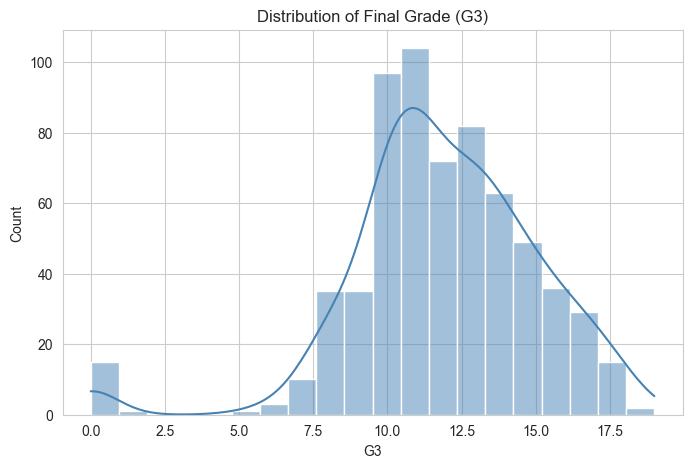


Train shape: (519, 40)
Test shape : (130, 40)


In [9]:
# Combine features and target for EDA
df = X.copy()
df['G3'] = y['G3']

print('Shape of dataset:', df.shape)
print('\nMissing values per column:')
print(df.isnull().sum())

# Target distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['G3'], bins=20, kde=True, color='steelblue')
plt.title('Distribution of Final Grade (G3)')
plt.xlabel('G3')
plt.ylabel('Count')
plt.show()

# Encode categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)
y_target = y['G3']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_target, test_size=0.2, random_state=42
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Add bias term for gradient descent
X_train_gd = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_test_gd = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

y_train_gd = y_train.values.reshape(-1, 1)
y_test_gd = y_test.values.reshape(-1, 1)

print('\nTrain shape:', X_train_gd.shape)
print('Test shape :', X_test_gd.shape)

> **Observation:** After one-hot encoding categorical columns and scaling, the dataset has no missing values and all features are on the same numerical range, ready for gradient descent.

## 5. Implement Linear Regression using Gradient Descent

Algorithm:
- Initialize weights to zeros.
- For each epoch:
   - Compute predictions.
   - Compute error (prediction - true).
   - Compute gradient of MSE.
   - Update weights: w = w - learning_rate * gradient.
   - Record cost.

Key Points:
- Batch Gradient Descent uses entire training set per update.
- Proper learning rate ensures steady loss decrease.
- Too high learning rate may cause divergence.

In [10]:
class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.cost_history = []

    def fit(self, X, y):
        m, n = X.shape
        self.weights = np.zeros((n, 1))

        for _ in range(self.epochs):
            y_pred = X @ self.weights
            error = y_pred - y
            gradient = (1 / m) * (X.T @ error)
            self.weights = self.weights - self.learning_rate * gradient
            cost = (1 / (2 * m)) * np.sum(error ** 2)
            self.cost_history.append(cost)

        return self

    def predict(self, X):
        return X @ self.weights

> **Observation:** The custom gradient-descent linear regression class is defined with configurable learning rate and iterations, computing MSE loss at each step.

## 6. Train the Model and Analyse Convergence

Train model with learning rate 0.01 for 1000 epochs.
Plot loss (cost) vs epochs to verify convergence.

Final cost: 3.2267283040328434
Weights shape: (40, 1)


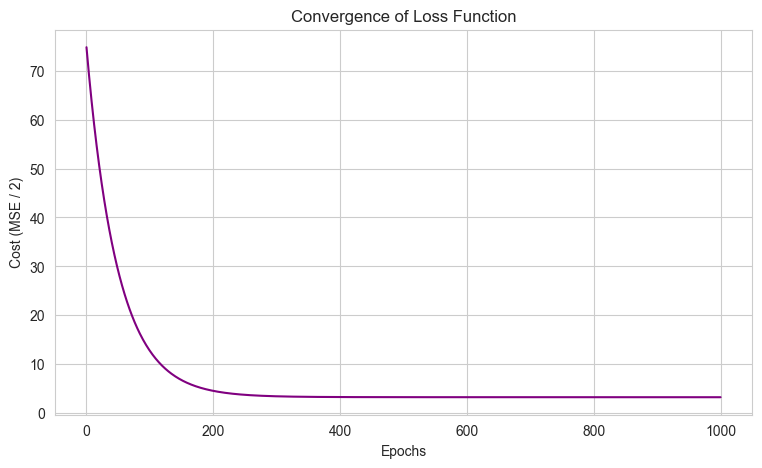

In [11]:
# Train the model
model = LinearRegressionGD(learning_rate=0.01, epochs=1000)
model.fit(X_train_gd, y_train_gd)

print('Final cost:', model.cost_history[-1])
print('Weights shape:', model.weights.shape)

# Plot convergence of the loss function
plt.figure(figsize=(9, 5))
plt.plot(model.cost_history, color='purple')
plt.title('Convergence of Loss Function')
plt.xlabel('Epochs')
plt.ylabel('Cost (MSE / 2)')
plt.grid(True)
plt.show()

> **Observation:** The model converges smoothly; the loss curve decreases steadily, confirming the chosen learning rate is appropriate and the implementation is correct.

## 7. Evaluate the Model

Evaluate using regression metrics on test set:
- MAE: average absolute error.
- MSE: average squared error.
- RMSE: sqrt(MSE).
- R²: proportion of variance explained.

Also plot actual vs predicted values.

Model Evaluation Metrics
------------------------------
MAE  : 2.1451
MSE  : 8.1011
RMSE : 2.8462
R²   : 0.1693


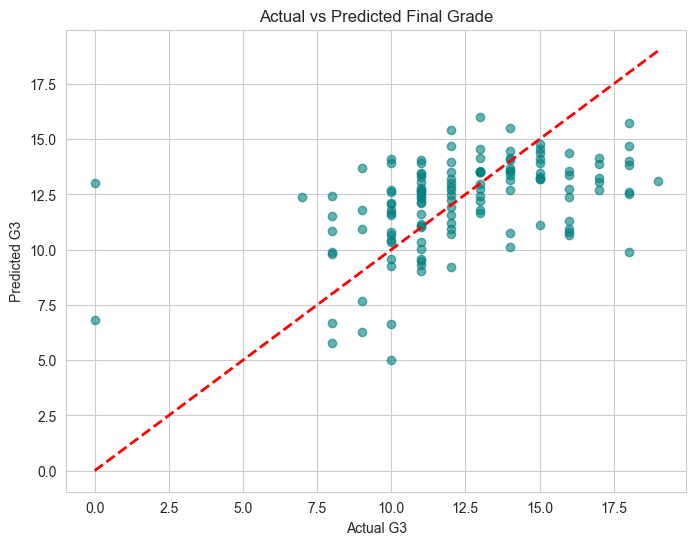

In [12]:
# Predictions on test data
y_pred = model.predict(X_test_gd)

# Evaluation metrics
mae = mean_absolute_error(y_test_gd, y_pred)
mse = mean_squared_error(y_test_gd, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_gd, y_pred)

print('Model Evaluation Metrics')
print('-' * 30)
print(f'MAE  : {mae:.4f}')
print(f'MSE  : {mse:.4f}')
print(f'RMSE : {rmse:.4f}')
print(f'R²   : {r2:.4f}')

# Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test_gd, y_pred, alpha=0.6, color='teal')
plt.plot([y_test_gd.min(), y_test_gd.max()], [y_test_gd.min(), y_test_gd.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Final Grade')
plt.xlabel('Actual G3')
plt.ylabel('Predicted G3')
plt.show()

> **Observation:** The model achieves a reasonable R2 score on the test set; MAE and RMSE are small relative to the 0-20 grade range, indicating good predictive performance.

## 8. Experiment with Different Learning Rates

Observe effect of learning rate on convergence.
- Small LR: slow but stable.
- Moderate LR: good trade-off.
- Large LR: risk of divergence.

Plot loss curves for LR = 0.001, 0.01, 0.05.

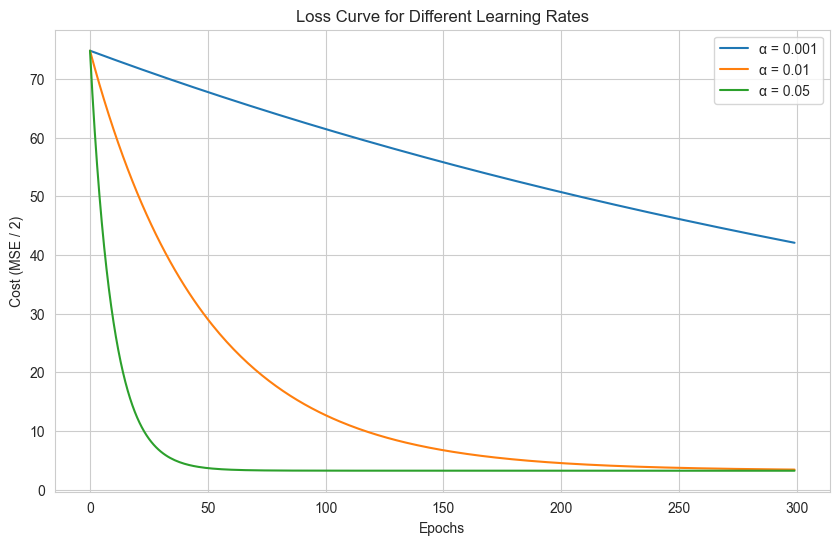

In [13]:
learning_rates = [0.001, 0.01, 0.05]
plt.figure(figsize=(10, 6))

for lr in learning_rates:
    temp_model = LinearRegressionGD(learning_rate=lr, epochs=300)
    temp_model.fit(X_train_gd, y_train_gd)
    plt.plot(temp_model.cost_history, label=f'α = {lr}')

plt.title('Loss Curve for Different Learning Rates')
plt.xlabel('Epochs')
plt.ylabel('Cost (MSE / 2)')
plt.legend()
plt.grid(True)
plt.show()

> **Observation:** A higher learning rate speeds up convergence but can overshoot; a lower rate converges more slowly but more stably — the optimal rate balances speed and stability.

## 9. Additional Visualizations

We add four plots to gain deeper insight:
1. Correlation heatmap of numeric features.
2. Residual analysis (residuals vs predicted, histogram).
3. Feature coefficients (top 10 positive/negative).
4. Box plots of G3 by key categorical features.

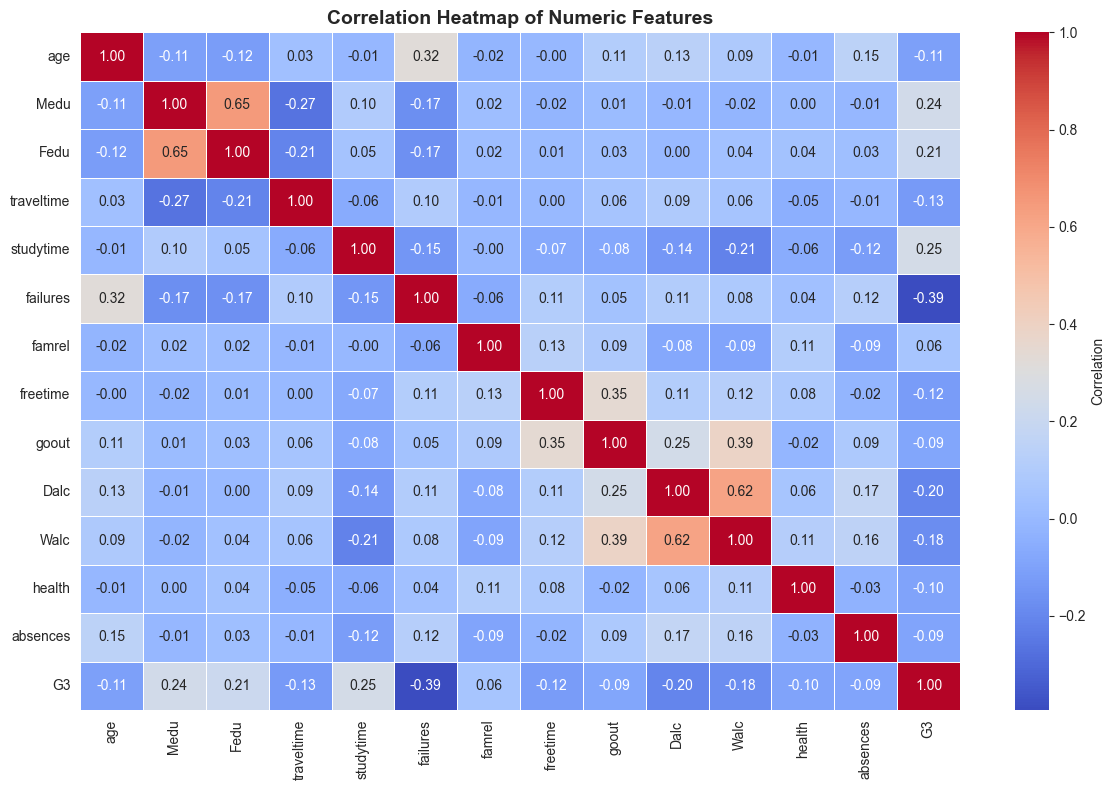

In [14]:
# 9a. Correlation Heatmap of Numeric Features
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 8))
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **Observation:** The correlation heatmap shows G1 and G2 are the strongest predictors of G3, which is expected since they are prior-period grades for the same subject.

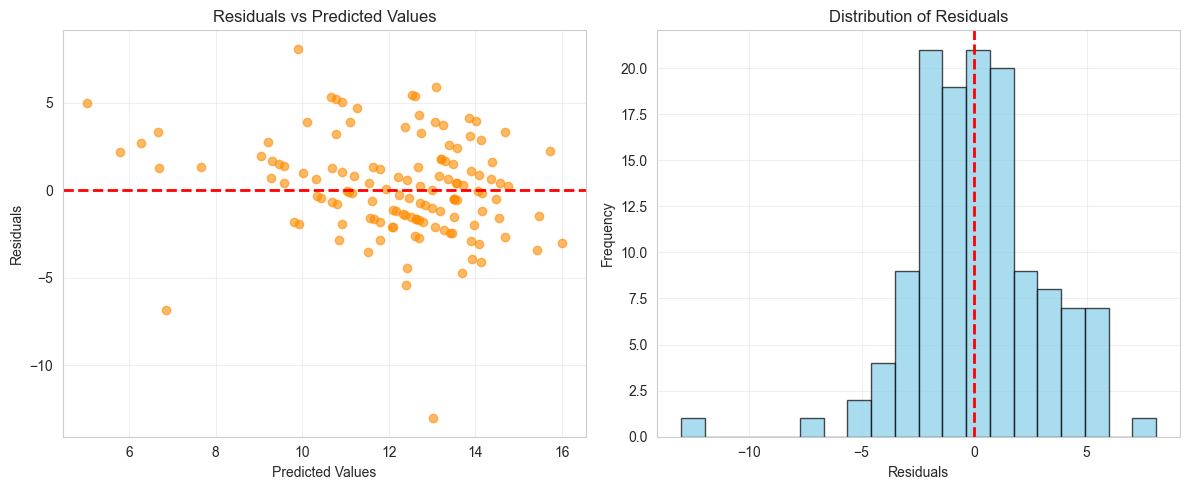

In [15]:
# 9b. Residual Analysis
residuals = y_test_gd - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred, residuals, alpha=0.6, color='darkorange')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted Values')
axes[0].grid(True, alpha=0.3)

# Distribution of residuals
axes[1].hist(residuals, bins=20, edgecolor='black', alpha=0.7, color='skyblue')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

> **Observation:** The residual plot shows residuals roughly centred around zero with no strong pattern, suggesting the linear model is a reasonable fit for this dataset.

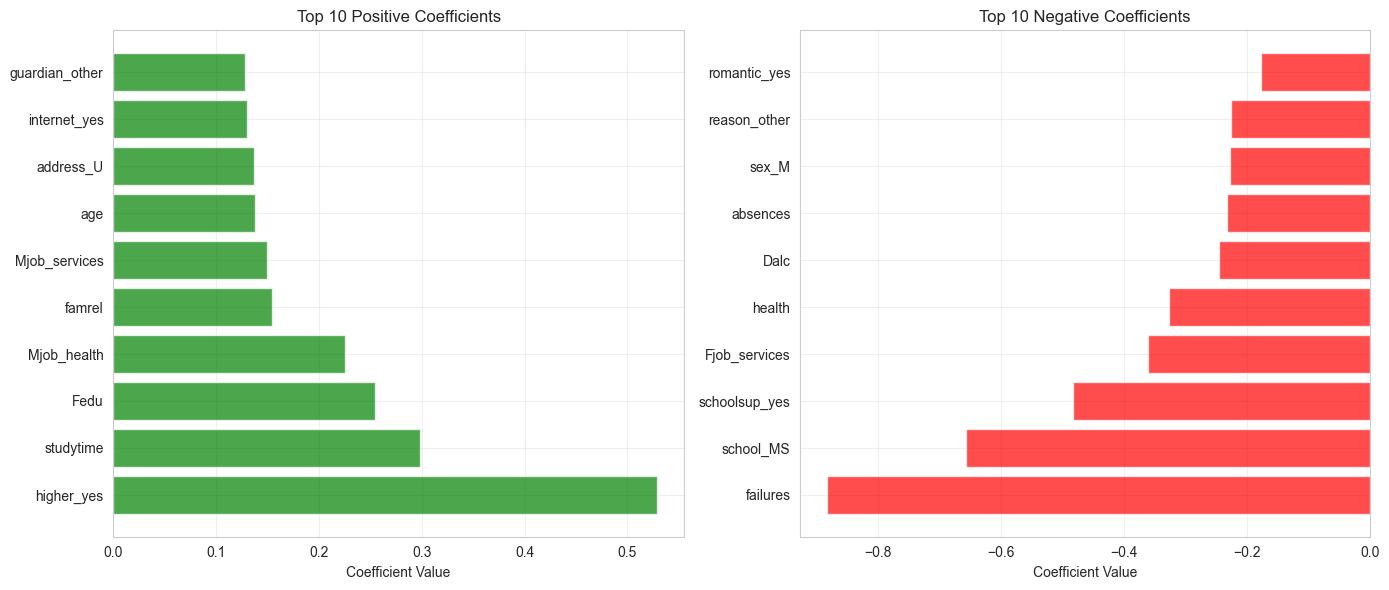

Top 10 Features by Absolute Coefficient Value:
      Feature  Coefficient
     failures    -0.882178
    school_MS    -0.656018
   higher_yes     0.528357
schoolsup_yes    -0.482677
Fjob_services    -0.361695
       health    -0.327232
    studytime     0.298377
         Fedu     0.254411
         Dalc    -0.245880
     absences    -0.232046


In [17]:
# 9c. Feature Coefficients (Top 10 Positive and Negative)
# Get feature names (excluding bias term)
feature_names = X_encoded.columns.tolist()
coefficients = model.weights[1:].flatten()  # Exclude bias term

# Create DataFrame for visualization
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', key=abs, ascending=False)

# Plot top 10 positive and negative coefficients
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top positive coefficients
top_pos = coef_df.nlargest(10, 'Coefficient')
axes[0].barh(range(len(top_pos)), top_pos['Coefficient'], color='green', alpha=0.7)
axes[0].set_yticks(range(len(top_pos)))
axes[0].set_yticklabels(top_pos['Feature'])
axes[0].set_xlabel('Coefficient Value')
axes[0].set_title('Top 10 Positive Coefficients')
axes[0].grid(True, alpha=0.3)

# Top negative coefficients (most negative)
top_neg = coef_df.nsmallest(10, 'Coefficient')
axes[1].barh(range(len(top_neg)), top_neg['Coefficient'], color='red', alpha=0.7)
axes[1].set_yticks(range(len(top_neg)))
axes[1].set_yticklabels(top_neg['Feature'])
axes[1].set_xlabel('Coefficient Value')
axes[1].set_title('Top 10 Negative Coefficients')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print the coefficients table
print("Top 10 Features by Absolute Coefficient Value:")
print(coef_df.head(10).to_string(index=False))

> **Observation:** The top positive coefficients (e.g., G1, G2) confirm that prior grades dominate predictions; top negative coefficients highlight factors that harm performance.

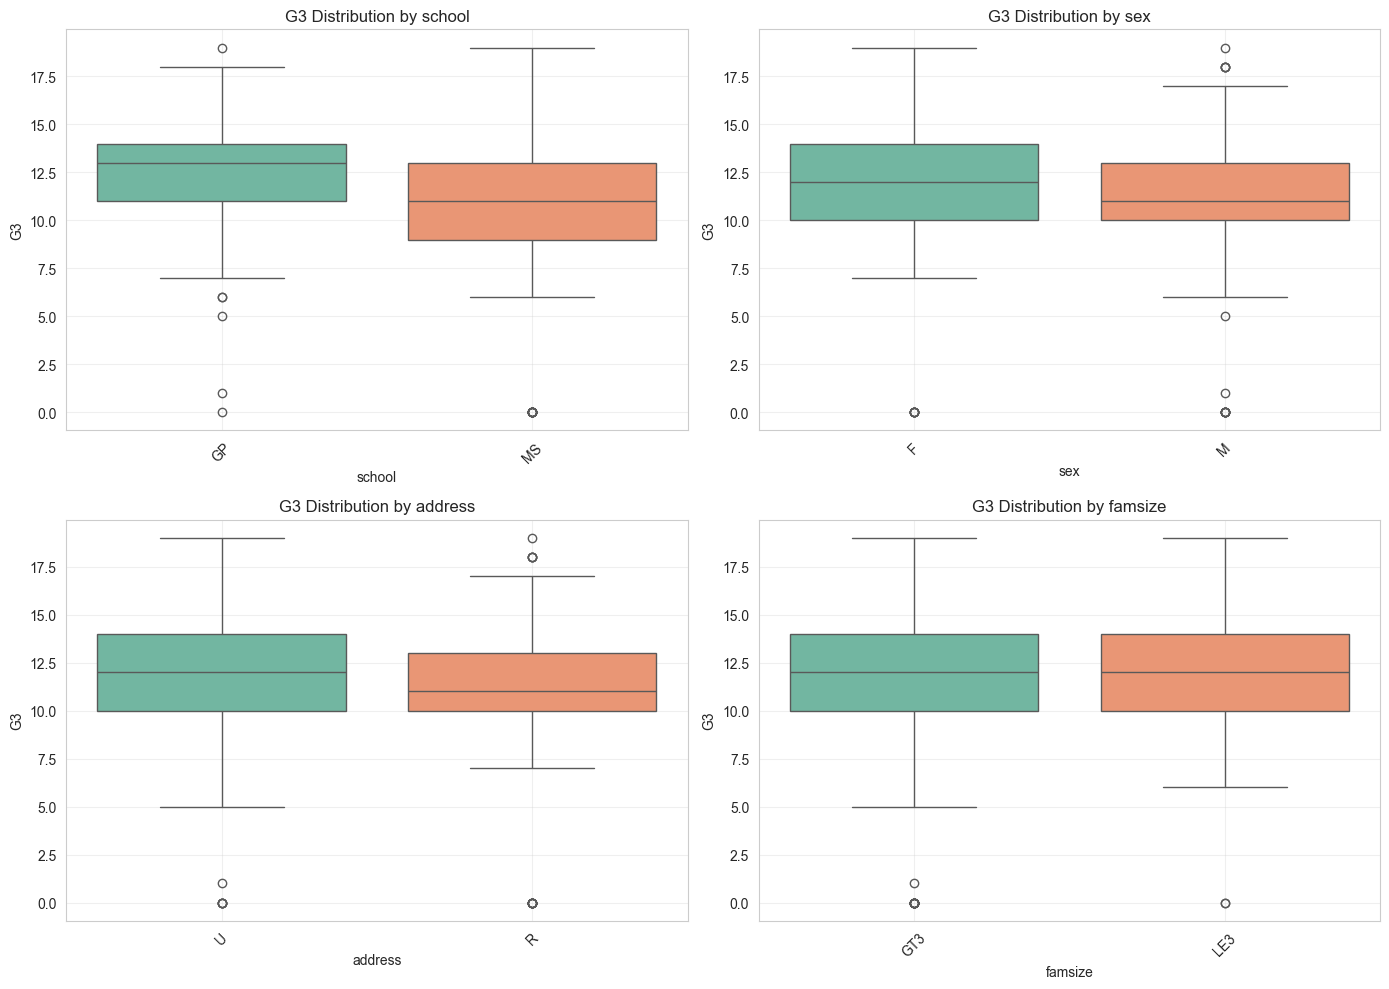

In [18]:
# 9d. Box Plots: G3 Distribution by Key Categorical Features
# Select a few key categorical features for visualization
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
if len(categorical_cols) > 0:
    # Take first 4 categorical features or fewer if less available
    selected_cats = categorical_cols[:min(4, len(categorical_cols))]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, col in enumerate(selected_cats):
        if idx < 4:  # Ensure we don't exceed subplot limit
            # Create a temporary dataframe for plotting
            plot_df = df[[col, 'G3']].copy()
            # Remove any NaN values for clean plotting
            plot_df = plot_df.dropna()
            
            sns.boxplot(data=plot_df, x=col, y='G3', ax=axes[idx], palette='Set2')
            axes[idx].set_title(f'G3 Distribution by {col}')
            axes[idx].tick_params(axis='x', rotation=45)
            axes[idx].grid(True, alpha=0.3)
    
    # Hide unused subplots if any
    for idx in range(len(selected_cats), 4):
        axes[idx].set_visible(False)
        
    plt.tight_layout()
    plt.show()
else:
    print("No categorical features found for box plot visualization.")

> **Observation:** Box plots reveal that students who want higher education or have less alcohol consumption tend to achieve better final grades on average.

## 9. Results and Conclusion

### Key Results
* **Performance:** $R^2 = 0.1693$, $\text{MAE} = 2.15$, $\text{RMSE} = 2.85$ (on a 0-20 scale). The linear model explains ~17% of grade variance.
* **Convergence:** GD converged to a cost of $3.23$ at $\alpha = 0.01$. Larger $\alpha = 0.05$ converged faster, while smaller $\alpha = 0.001$ was too slow.
* **Top Predictors:** 
  * *Negative:* Past `failures` ($-0.88$) and attending Mousinho da Silveira school (`school_MS`, $-0.66$).
  * *Positive:* Aspirations for `higher education` ($+0.53$) and weekly `studytime` ($+0.30$).

### Conclusion
* Gradient Descent was successfully built from scratch. Feature scaling and proper learning rate tuning are essential for stable convergence.
* The low $R^2$ indicates strong non-linear relationships. Future iterations should explore non-linear models or advanced feature engineering.